In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
import joblib

In [27]:
df = pd.read_csv("cricket_ticket_forecasting_dataset.csv")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (756, 29)


,id,date,team1,team2,venue,winner,day_of_week,team1_rank,team2_rank,weather_temp,...,social_media_mentions,search_trends_index,promotion_flag,past_30d_avg_sales,expected_attendance,actual_attendance,venue_capacity,traffic_index,special_event_flag,time_of_day
0,1,05-04-2017,Sunrisers Hyderabad,Royal Challengers Bangalore,"Rajiv Gandhi International Stadium, Uppal",Sunrisers Hyderabad,Wednesday,4,6,33.0,...,19360,81,0,43639,43419,41388,62134,3,1,Day
1,2,06-04-2017,Mumbai Indians,Rising Pune Supergiant,Maharashtra Cricket Association Stadium,Rising Pune Supergiant,Thursday,6,7,29.0,...,18680,26,1,30561,37804,38404,54136,4,0,Day
2,3,07-04-2017,Gujarat Lions,Kolkata Knight Riders,Saurashtra Cricket Association Stadium,Kolkata Knight Riders,Friday,7,6,23.0,...,7229,94,1,25496,28576,28668,35806,4,0,Night
3,4,08-04-2017,Rising Pune Supergiant,Kings XI Punjab,Holkar Cricket Stadium,Kings XI Punjab,Saturday,7,7,33.0,...,17509,99,0,43244,54435,52275,63086,2,0,Night
4,5,08-04-2017,Royal Challengers Bangalore,Delhi Daredevils,M Chinnaswamy Stadium,Royal Challengers Bangalore,Saturday,6,5,34.0,...,16147,23,1,30633,27102,26214,42152,1,1,Night


In [28]:
print("Missing Values:\n", df.isnull().sum())

Missing Values:
 id                             0
date                           0
team1                          0
team2                          0
venue                          0
winner                         4
day_of_week                    0
team1_rank                     0
team2_rank                     0
weather_temp                 158
weather_rain                 158
ticket_price_avg               0
historical_avg_attendance      0
ticket_price_min               0
ticket_price_max               0
tickets_sold                   0
dynamic_pricing_flag           0
holiday_flag                   0
ad_spend                       0
social_media_mentions          0
search_trends_index            0
promotion_flag                 0
past_30d_avg_sales             0
expected_attendance            0
actual_attendance              0
venue_capacity                 0
traffic_index                  0
special_event_flag             0
time_of_day                    0
dtype: int64


In [29]:
drop_cols = ['id', 'team1', 'team2', 'winner', 'date', 'venue']
df = df.drop(columns=drop_cols, errors='ignore')

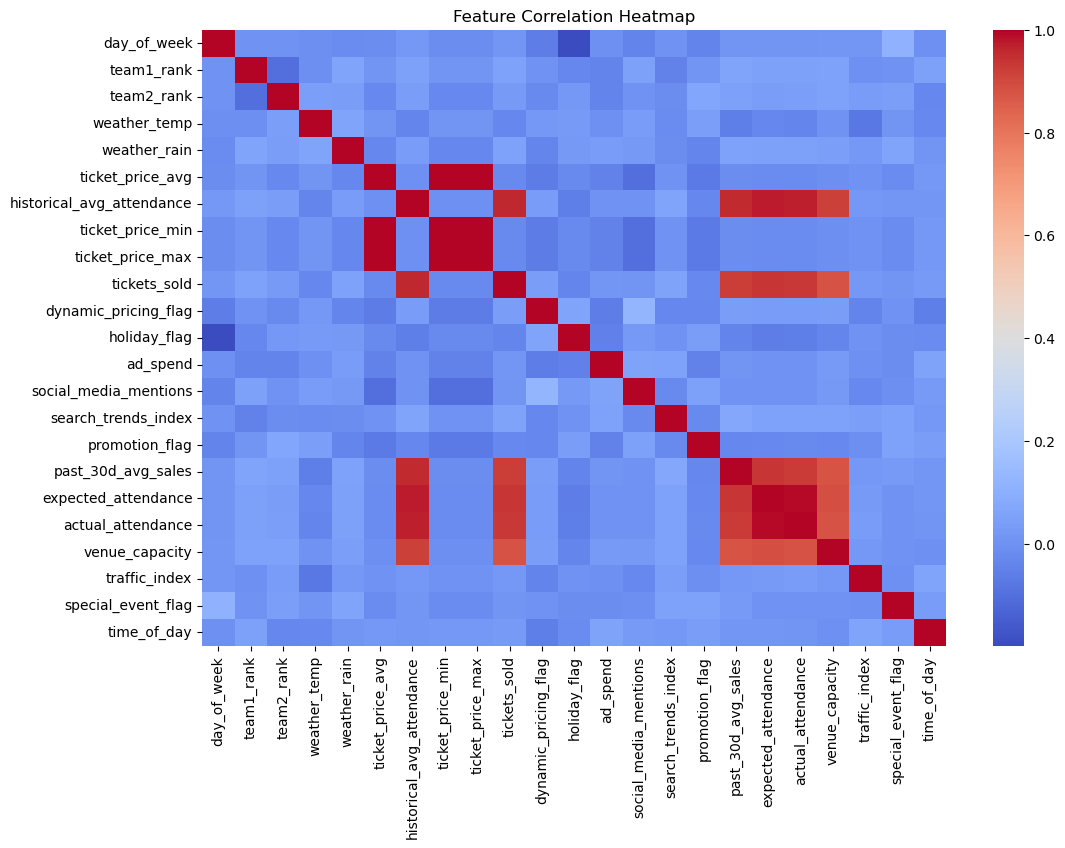

In [35]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

In [31]:
if "date" in df.columns:
    try:
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df["year"] = df["date"].dt.year.fillna(0).astype(int)
        df["month"] = df["date"].dt.month.fillna(0).astype(int)
        df["day"] = df["date"].dt.day.fillna(0).astype(int)
        df = df.drop(columns=["date"])
    except Exception as e:
        print("Date parsing failed:", e)
        df = df.drop(columns=["date"], errors="ignore")

In [36]:
drop_cols = ['id', 'team1', 'team2', 'winner', 'venue']
df = df.drop(columns=drop_cols, errors='ignore')

In [37]:
cat_cols = df.select_dtypes(include=['object']).columns
print("Categorical Columns Before Encoding:", cat_cols.tolist())

for col in cat_cols:
    df[col] = df[col].astype(str)                 # ensure strings
    df[col] = df[col].fillna("Unknown")           # handle NaNs
    df[col] = LabelEncoder().fit_transform(df[col])


Categorical Columns Before Encoding: []


In [40]:
target = 'tickets_sold'   # or 'actual_attendance'
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset!")

X = df.drop(columns=[target])
y = df[target]

# Impute missing values (numeric cols only)
num_cols = X.select_dtypes(include=[np.number]).columns
imputer = SimpleImputer(strategy="median")
X[num_cols] = imputer.fit_transform(X[num_cols])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [41]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
    "MLP": MLPRegressor(hidden_layer_sizes=(64,32), max_iter=500, random_state=42)
}

results = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        r2 = r2_score(y_test, preds)
        mae = mean_absolute_error(y_test, preds)
        rmse = np.sqrt(mean_squared_error(y_test, preds))

        results[name] = {"R2": r2, "MAE": mae, "RMSE": rmse}
        print(f"{name} -> R2: {r2:.3f}, MAE: {mae:.3f}, RMSE: {rmse:.3f}")
    except Exception as e:
        print(f"❌ {name} failed with error: {e}")


LinearRegression -> R2: 0.921, MAE: 2365.398, RMSE: 2817.459
Ridge -> R2: 0.922, MAE: 2337.177, RMSE: 2803.565
Lasso -> R2: 0.922, MAE: 2337.355, RMSE: 2801.250
RandomForest -> R2: 0.916, MAE: 2415.806, RMSE: 2908.378
XGBoost -> R2: 0.898, MAE: 2578.139, RMSE: 3193.326
MLP -> R2: -0.138, MAE: 9135.357, RMSE: 10685.369


D:\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,R2,MAE,RMSE
LinearRegression,0.920916,2365.397934,2817.458888
Ridge,0.921694,2337.177489,2803.565421
Lasso,0.921823,2337.354603,2801.249730
RandomForest,0.915729,2415.805888,2908.378274
XGBoost,0.898407,2578.138826,3193.326278
MLP,-0.137508,9135.357498,10685.368530


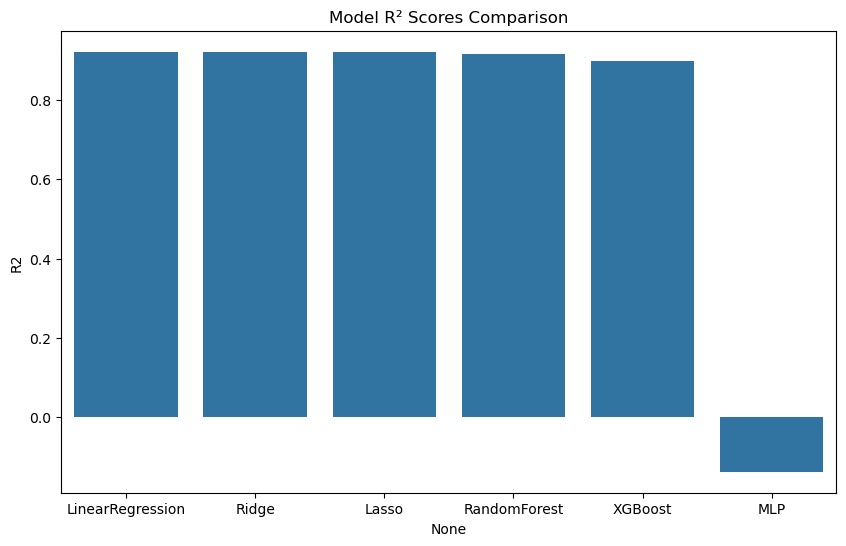

In [42]:
# 7. Compare Models
# -------------------------------
results_df = pd.DataFrame(results).T
display(results_df)

plt.figure(figsize=(10,6))
sns.barplot(x=results_df.index, y=results_df["R2"])
plt.title("Model R² Scores Comparison")
plt.show()

In [43]:
# 8. Best Model & Save
# -------------------------------
if not results_df.empty:
    best_model = results_df["R2"].idxmax()
    print("\nBest Model:", best_model, results[best_model])

    joblib.dump(models[best_model], "best_ticket_forecast_model.pkl")
    print("✅ Best model saved as best_ticket_forecast_model.pkl")
else:
    print("⚠ No models trained successfully. Check preprocessing steps.")



Best Model: Lasso {'R2': 0.9218229882806909, 'MAE': 2337.354602910875, 'RMSE': 2801.249730282843}
✅ Best model saved as best_ticket_forecast_model.pkl
